# Réalisation du plan d'expérience de l'algorithme Génétique

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistiques sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- $i= 50$ : nombre d'itérations (générations) par instance

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itération
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimun et le maximum
- graphiques:
    - Trajectoire
    - influence de chaque paramètre (Heatmap à double entrée (type github)) -> tendance générale
    - Distance à la borne (`gap`)
- Meilleur paramètres

In [1]:
import sys

import numpy as np
import networkx as nx

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

from graph_generator import generate_graph
from src.algorithms.genetic import resolve_by_genetic


### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `NB_GENERATIONS` : nombre de générations de l'algorithme par instance

In [2]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_GENERATIONS: int = 50


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances


### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [3]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference


### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [4]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")


N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


## Étude de trajectoire

On exécute l'algorithme génétique sur une instance de référence (N=20, seed=0) en enregistrant le meilleur coût à chaque génération pour visualiser la convergence.

Paramètres utilisés :
- `population_size` : taille de la population
- `generations` : nombre de générations
- `crossover_rate` : probabilité de croisement (OX)
- `mutation_rate` : probabilité de mutation (swap)
- `tournament_size` : taille du tournoi de sélection
- `elite_size` : nombre d'individus élites conservés sans modification

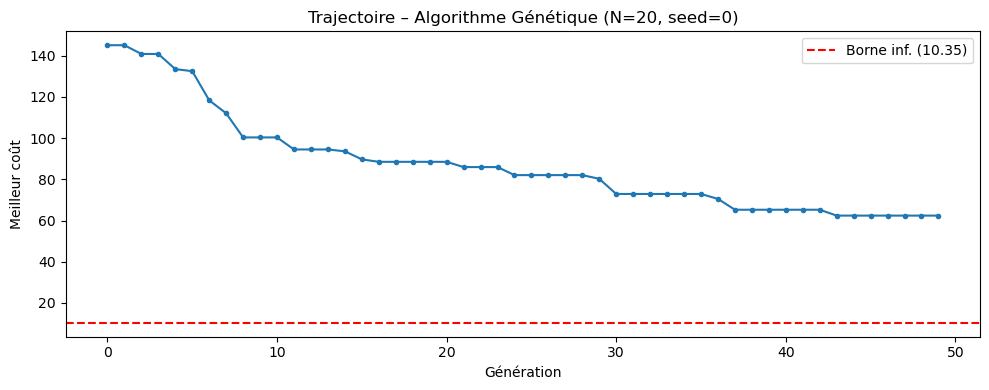

In [12]:
import random
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from helper import calculate_tour_cost_with_penalty


def _generate_random_individual(nodes: list[int]) -> list[int]:
    individual = nodes.copy()
    random.shuffle(individual)
    return individual


def _ordered_crossover(parent1: list[int], parent2: list[int]) -> list[int]:
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [-1] * size
    child[start : end + 1] = parent1[start : end + 1]
    pointer = end + 1
    for gene in parent2[end + 1 :] + parent2[: end + 1]:
        if gene not in child:
            if pointer >= size:
                pointer = 0
            child[pointer] = gene
            pointer += 1
    return child


def _swap_mutation(individual: list[int], mutation_rate: float) -> list[int]:
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual


def _tournament_selection(
    population: list[list[int]], costs: list[float], tournament_size: int
) -> list[int]:
    participants = random.sample(list(zip(population, costs)), tournament_size)
    participants.sort(key=lambda item: item[1])
    return participants[0][0].copy()


def genetic_trajectory(
    graph: nx.Graph,
    population_size: int = 50,
    generations: int = NB_GENERATIONS,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.2,
    tournament_size: int = 3,
    elite_size: int = 2,
) -> list[float]:
    """Exécute l'algorithme génétique et retourne la trajectoire du meilleur coût par génération."""
    nodes: list[int] = list(graph.nodes())
    population = [_generate_random_individual(nodes) for _ in range(population_size)]
    best_cost: float = float("inf")
    trajectory: list[float] = []

    for _ in range(generations):
        costs = [calculate_tour_cost_with_penalty(graph, ind) for ind in population]

        for ind, cost in zip(population, costs):
            if cost < best_cost:
                best_cost = cost

        trajectory.append(best_cost)

        sorted_pop = [ind for _, ind in sorted(zip(costs, population), key=lambda x: x[0])]
        new_population: list[list[int]] = sorted_pop[:elite_size]

        while len(new_population) < population_size:
            p1 = _tournament_selection(population, costs, tournament_size)
            p2 = _tournament_selection(population, costs, tournament_size)
            child = _ordered_crossover(p1, p2) if random.random() < crossover_rate else p1.copy()
            child = _swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    return trajectory


# Instance de référence : N=20, seed=0
_, ref_graph, ref_lb = instances[20][0]
traj = genetic_trajectory(ref_graph, generations=NB_GENERATIONS)

plt.figure(figsize=(10, 4))
plt.plot(traj, marker="o", markersize=3, linewidth=1.5)
plt.axhline(ref_lb, color="red", linestyle="--", label=f"Borne inf. ({ref_lb:.2f})")
plt.xlabel("Génération")
plt.ylabel("Meilleur coût")
plt.title("Trajectoire – Algorithme Génétique (N=20, seed=0)")
plt.legend()
plt.tight_layout()
plt.show()


## Étude de l'influence des paramètres

On fait varier les deux paramètres principaux de l'algorithme génétique :
- `population_size` $\in \{20, 50, 100, 200\}$
- `mutation_rate` $\in \{0.05, 0.1, 0.2, 0.3, 0.5\}$

Les autres paramètres sont fixés à leurs valeurs par défaut (`generations=50`, `crossover_rate=0.8`, `tournament_size=3`, `elite_size=2`).
Pour chaque combinaison, on calcule le gap moyen sur toutes les instances (toutes tailles, tous seeds).
Le résultat est affiché sous forme de heatmap (type GitHub).

pop_size=  20 | mut_rate=0.05 | gap moyen=265351.02%
pop_size=  20 | mut_rate=0.10 | gap moyen=814.09%
pop_size=  20 | mut_rate=0.20 | gap moyen=724.89%
pop_size=  20 | mut_rate=0.30 | gap moyen=140736.13%
pop_size=  20 | mut_rate=0.50 | gap moyen=669.38%
pop_size=  50 | mut_rate=0.05 | gap moyen=699.67%
pop_size=  50 | mut_rate=0.10 | gap moyen=642.32%
pop_size=  50 | mut_rate=0.20 | gap moyen=593.52%
pop_size=  50 | mut_rate=0.30 | gap moyen=577.67%
pop_size=  50 | mut_rate=0.50 | gap moyen=575.10%
pop_size= 100 | mut_rate=0.05 | gap moyen=567.81%
pop_size= 100 | mut_rate=0.10 | gap moyen=573.77%
pop_size= 100 | mut_rate=0.20 | gap moyen=544.82%
pop_size= 100 | mut_rate=0.30 | gap moyen=540.48%
pop_size= 100 | mut_rate=0.50 | gap moyen=594.21%
pop_size= 200 | mut_rate=0.05 | gap moyen=518.68%
pop_size= 200 | mut_rate=0.10 | gap moyen=511.36%
pop_size= 200 | mut_rate=0.20 | gap moyen=534.51%
pop_size= 200 | mut_rate=0.30 | gap moyen=545.23%
pop_size= 200 | mut_rate=0.50 | gap moyen=62

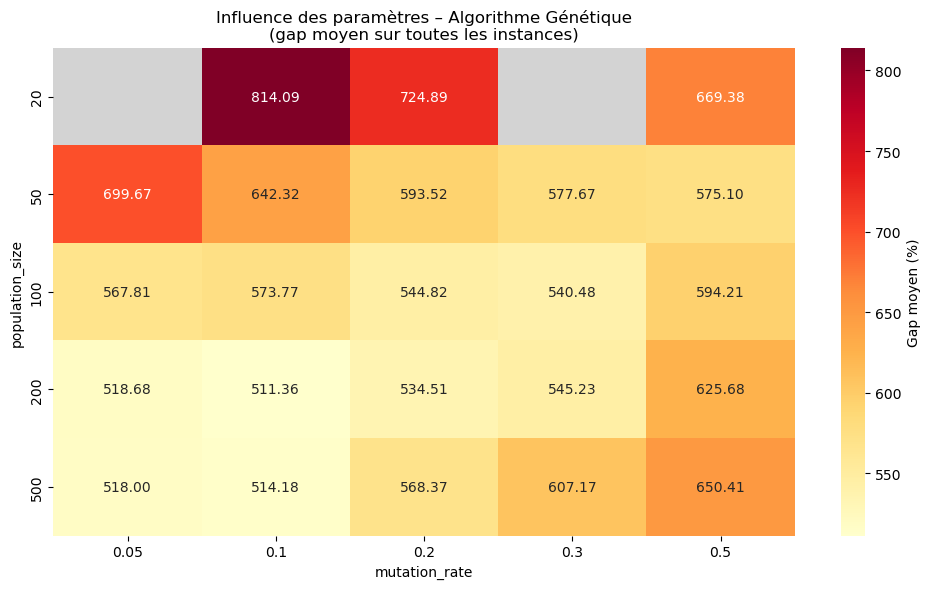

In [20]:
import itertools
import pandas as pd
import seaborn as sns

POP_SIZE_VALUES: list[int] = [20, 50, 100, 200, 500]
MUTATION_RATE_VALUES: list[float] = [0.05, 0.1, 0.2, 0.3, 0.5]

# Résultats : (population_size, mutation_rate) -> gap moyen
results: dict[tuple[int, float], list[float]] = {}

for pop_size, mut_rate in itertools.product(POP_SIZE_VALUES, MUTATION_RATE_VALUES):
    gaps: list[float] = []
    for n in N_VALUES:
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_genetic(
                graph,
                population_size=pop_size,
                generations=NB_GENERATIONS,
                mutation_rate=mut_rate,
            )
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
    results[(pop_size, mut_rate)] = gaps
    print(f"pop_size={pop_size:4d} | mut_rate={mut_rate:.2f} | gap moyen={np.mean(gaps):.2f}%")

# Construction du DataFrame pour la heatmap
mean_gaps = {
    (pop_size, mut_rate): np.mean(gaps)
    for (pop_size, mut_rate), gaps in results.items()
}
heatmap_data = pd.DataFrame(
    index=POP_SIZE_VALUES,
    columns=MUTATION_RATE_VALUES,
    data=[
        [mean_gaps[(pop_size, mut_rate)] for mut_rate in MUTATION_RATE_VALUES]
        for pop_size in POP_SIZE_VALUES
    ],
    dtype=float,
)
heatmap_data.index.name = "population_size"
heatmap_data.columns.name = "mutation_rate"
heatmap_data = heatmap_data.where(heatmap_data <= 1000, np.nan)

plt.figure(figsize=(10, 6))

ax = plt.axes()
ax.set_facecolor("lightgray")

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Gap moyen (%)"},
)
plt.title("Influence des paramètres – Algorithme Génétique\n(gap moyen sur toutes les instances)")
plt.tight_layout()
plt.show()


## Distance à la borne (gap) par taille de graphe

On exécute l'algorithme génétique avec les paramètres par défaut (`generations=50`, `population_size=50`, `crossover_rate=0.8`, `mutation_rate=0.2`, `tournament_size=3`, `elite_size=2`) sur toutes les instances et on trace le gap en fonction de N.

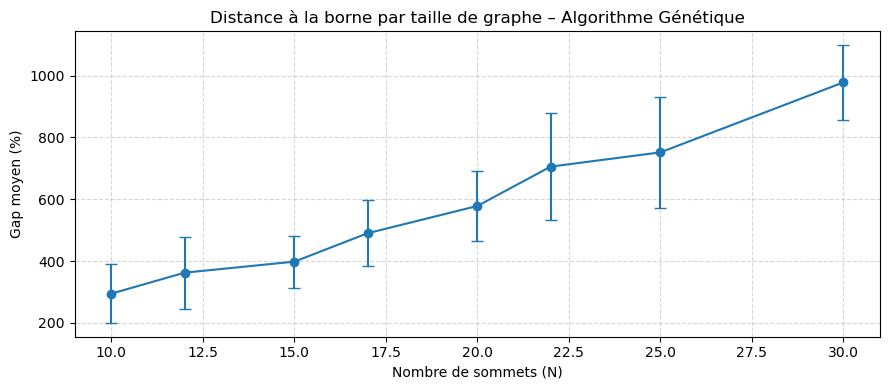

In [7]:
gap_by_n: dict[int, list[float]] = {}

for n in N_VALUES:
    gaps: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_genetic(graph, generations=NB_GENERATIONS)
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps.append(gap)
    gap_by_n[n] = gaps

means = [np.mean(gap_by_n[n]) for n in N_VALUES]
stds  = [np.std(gap_by_n[n])  for n in N_VALUES]

plt.figure(figsize=(9, 4))
plt.errorbar(N_VALUES, means, yerr=stds, marker="o", capsize=4, linewidth=1.5)
plt.xlabel("Nombre de sommets (N)")
plt.ylabel("Gap moyen (%)")
plt.title("Distance à la borne par taille de graphe – Algorithme Génétique")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Statistiques descriptives

Tableau récapitulatif : meilleur coût, moyenne, médiane, écart-type, min et max — par taille de graphe.

In [8]:
rows: list[dict] = []
for n in N_VALUES:
    costs: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_genetic(graph, generations=NB_GENERATIONS)
        costs.append(cost)
    rows.append({
        "N": n,
        "Meilleur": np.min(costs),
        "Moyenne": np.mean(costs),
        "Médiane": np.median(costs),
        "Écart-type": np.std(costs),
        "Min": np.min(costs),
        "Max": np.max(costs),
        "Gap moyen (%)": np.mean([compute_gap(c, ref) for (_, __, ref), c in zip(instances[n], costs)]),
    })

stats_df = pd.DataFrame(rows).set_index("N")
stats_df.round(3)


,Meilleur,Moyenne,Médiane,Écart-type,Min,Max,Gap moyen (%)
N,,,,,,,
10,35.15,48.055,46.225,10.223,35.15,69.15,330.126
12,37.50,54.090,47.625,13.527,37.50,78.00,351.397
15,40.65,58.390,57.375,12.059,40.65,81.30,440.674
17,51.45,67.350,65.850,8.883,51.45,81.90,539.804
20,62.25,74.950,75.600,9.970,62.25,91.05,586.519
22,63.30,82.355,85.250,12.725,63.30,103.60,745.810
25,74.10,95.645,96.075,12.169,74.10,112.50,805.872
30,90.60,116.340,109.150,19.525,90.60,152.50,1044.721


## Meilleurs paramètres

On identifie la combinaison `(population_size, mutation_rate)` qui minimise le gap moyen sur l'ensemble des instances.

In [9]:
best_params = min(mean_gaps, key=mean_gaps.get)
best_gap    = mean_gaps[best_params]

print(f"Meilleurs paramètres :")
print(f"  population_size = {best_params[0]}")
print(f"  mutation_rate   = {best_params[1]:.2f}")
print(f"  Gap moyen       = {best_gap:.2f}%")


Meilleurs paramètres :
  population_size = 200
  mutation_rate   = 0.10
  Gap moyen       = 496.28%
